# Exploratory Analysis

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sys.path.append(os.path.join('..', '..', 'packages'))
from alexandria.regression import stratify_continuous

In [2]:
dataset = pd.read_parquet('california_housing.parquet', engine='pyarrow')
target = 'med_houseval'
dataset.head()

,med_inc,house_age,ave_rooms,ave_bedrms,population,ave_occup,latitude,longitude,med_houseval
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   med_inc       20640 non-null  float64
 1   house_age     20640 non-null  float64
 2   ave_rooms     20640 non-null  float64
 3   ave_bedrms    20640 non-null  float64
 4   population    20640 non-null  float64
 5   ave_occup     20640 non-null  float64
 6   latitude      20640 non-null  float64
 7   longitude     20640 non-null  float64
 8   med_houseval  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Distributions

Both house age and the median house value have their last bin higher than the other ones, which indicates possible sample value limit.
Average variables and population are heavily skewed.

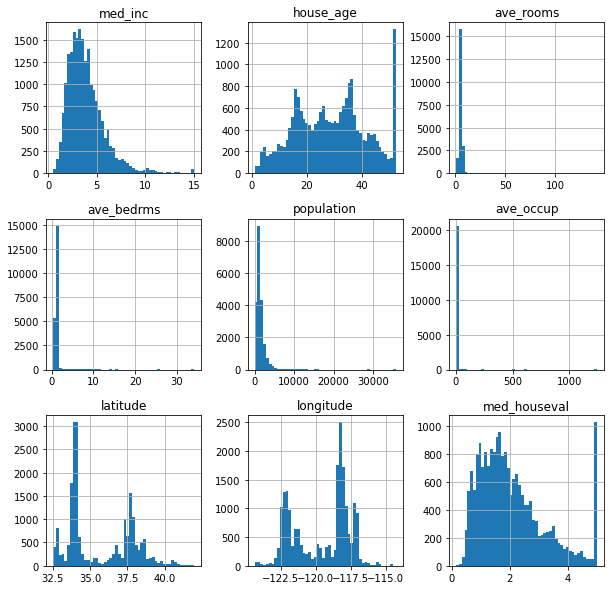

In [4]:
axes = dataset.hist(bins=50, figsize=(10,10))

## Latitude x Longitude

<AxesSubplot:title={'center':'Latitude x Longitude'}, xlabel='longitude', ylabel='latitude'>

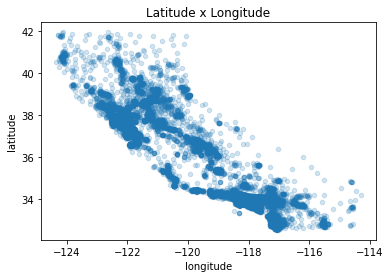

In [5]:
dataset.plot.scatter(x='longitude', y='latitude', alpha=0.2, title='Latitude x Longitude')

## Stratifying data
Startifying target variable for mantaining its distribution

In [12]:
categories = stratify_continuous(bin_size=1.5, data=dataset[target])
dataset[categories.name] = categories
dataset

,med_inc,house_age,ave_rooms,ave_bedrms,population,ave_occup,latitude,longitude,med_houseval,cat_med_houseval
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,3.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.0
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0.0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0.0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0.0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0.0


<AxesSubplot:title={'center':'Categorical Histogram'}, ylabel='Frequency'>

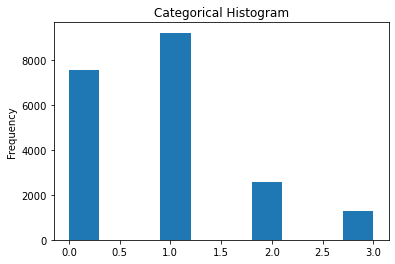

In [15]:
dataset['cat_med_houseval'].plot.hist(title='Categorical Histogram')